<a href="https://colab.research.google.com/github/tomasarenase0512/pruebatecnica/blob/main/Prueba_tecnica_estructurador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  MODELO KMV — BVC

[1/4] Descargando precios históricos...

[2/4] Obteniendo datos fundamentales...
                 Equity_E           STD           LTD  Default_Point
Éxito        5.606774e+12  1.992729e+12  1.506780e+11   2.068068e+12
Ecopetrol    1.001192e+14  6.752186e+12  1.075211e+14   6.051271e+13
GEB          2.882890e+13  9.298060e+11  1.976298e+13   1.081130e+13
Bancolombia  8.298224e+09  0.000000e+00  1.676612e+13   8.383060e+12
Cemargos     1.608856e+13  7.305640e+11  2.070647e+12   1.765888e+12

[3/4] Calculando KMV por empresa...

[4/4] Generando gráfico...
  ✔  Gráfico guardado en: kmv_bvc.png


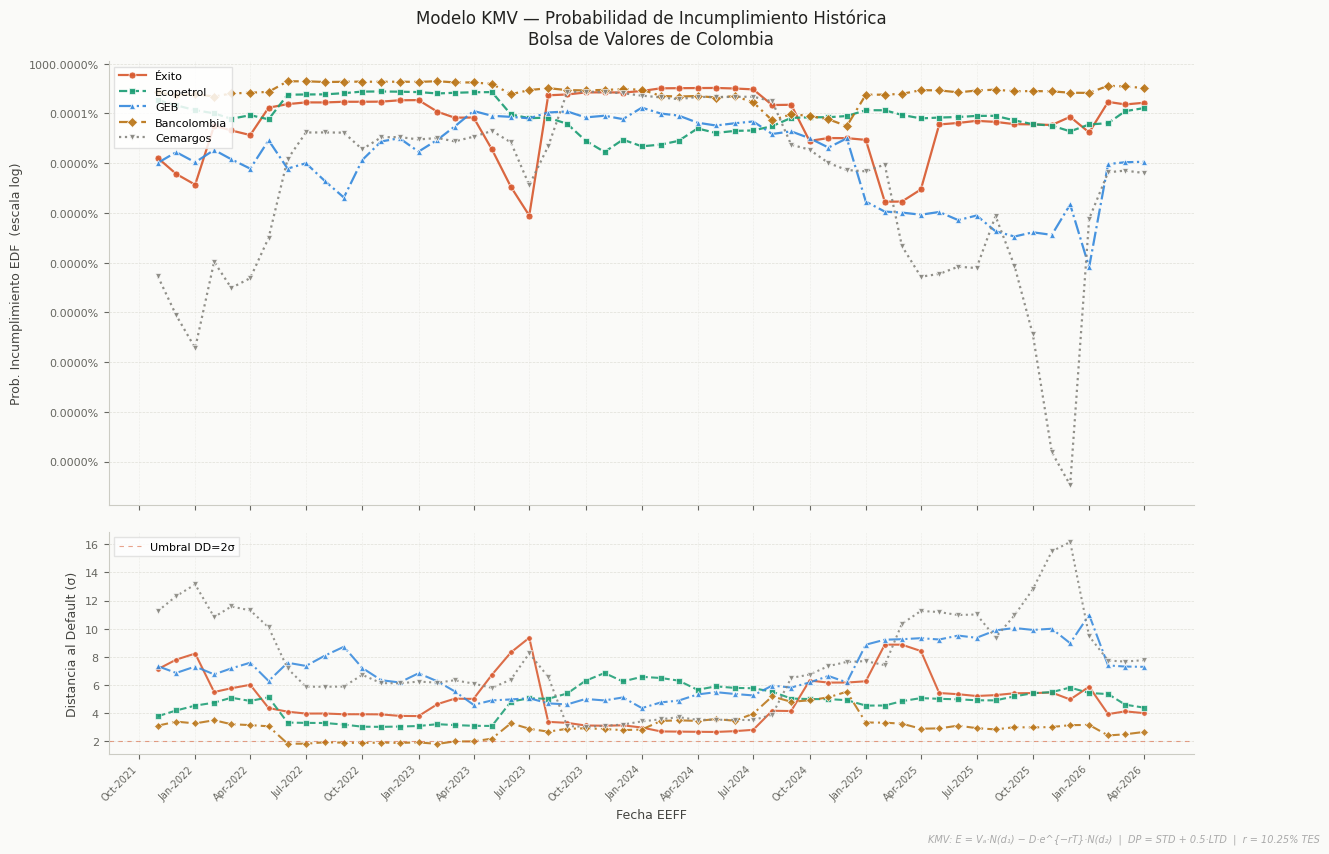


📊 Tabla resumen — valores más recientes
───────────────────────────────────────────────────────
             DD (σ)  EDF (%)  σ_E anual         Señal
Empresa                                              
Éxito         3.996  0.00323     0.4476    🟢 Solvente
Ecopetrol     4.386  0.00058     0.3601    🟢 Solvente
GEB           7.287  0.00000     0.2513    🟢 Solvente
Bancolombia   2.663  0.38710     0.3741  🟡 Vigilancia
Cemargos      7.765  0.00000     0.3366    🟢 Solvente

  Éxito         DD=4.00σ  EDF=0.0032%  🟢 Solvente
  Ecopetrol     DD=4.39σ  EDF=0.0006%  🟢 Solvente
  GEB           DD=7.29σ  EDF=0.0000%  🟢 Solvente
  Bancolombia   DD=2.66σ  EDF=0.3871%  🟡 Vigilancia
  Cemargos      DD=7.76σ  EDF=0.0000%  🟢 Solvente


In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from scipy.stats import norm
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# 0. PARÁMETROS GLOBALES
# ─────────────────────────────────────────────────────────────────────────────
TICKERS = {
    "Éxito":     "EXITO.CL",
    "Ecopetrol": "ECOPETROL.CL",
    "GEB":       "GEB.CL",
    "Bancolombia":       "CIB",
    "Cemargos":    "CEMARGOS.CL",
}

# Colores y estilos por empresa (mapea con identidad visual)
ESTILOS = {
    "Éxito":     {"color": "#D85A30", "marker": "o",  "ls": "-"},
    "Ecopetrol": {"color": "#1D9E75", "marker": "s",  "ls": "--"},
    "GEB":       {"color": "#378ADD", "marker": "^",  "ls": "-."},
    "Bancolombia":   {"color": "#BA7517", "marker": "D",  "ls": (0,(5,2,1,2))},
    "Cemargos":    {"color": "#888780", "marker": "v",  "ls": ":"},
}

TASA_RF = 0.13   # TES Colombia — actualiza según curva vigente
T       = 1.0      # Horizonte 1 año

# ─────────────────────────────────────────────────────────────────────────────
# 1. DESCARGA DE PRECIOS Y VOLATILIDAD HISTÓRICA MENSUAL
# ─────────────────────────────────────────────────────────────────────────────
def descargar_precios(tickers: dict, period: str = "5y") -> dict:
    """Descarga precios mensuales y calcula retornos log + volatilidad anual."""
    resultados = {}
    for nombre, ticker in tickers.items():
        accion = yf.Ticker(ticker)
        df = accion.history(period=period, interval="1mo")

        if df.empty:
            print(f"  ⚠  Sin datos: {nombre} ({ticker})")
            continue

        df = df[["Close", "Volume"]].copy()
        df.columns = ["Cierre", "Volumen"]
        df.index   = pd.to_datetime(df.index.tz_localize(None))  # quitar tz

        # Retorno logarítmico mensual
        df["Ret_Log"] = np.log(df["Cierre"] / df["Cierre"].shift(1))

        # Volatilidad anualizada rolling 12 meses (min 6 obs.)
        df["Vol_Anual"] = df["Ret_Log"].rolling(12, min_periods=6).std() * np.sqrt(12)

        resultados[nombre] = df.dropna(subset=["Vol_Anual"])

    return resultados


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATOS FUNDAMENTALES (Default Point)
# ─────────────────────────────────────────────────────────────────────────────
def obtener_fundamentales(tickers: dict) -> pd.DataFrame:
    """Extrae acciones en circulación, precio, STD, LTD y Default Point."""
    registros = {}
    for nombre, ticker in tickers.items():
        empresa = yf.Ticker(ticker)
        try:
            info      = empresa.info
            acciones  = info.get("sharesOutstanding", np.nan)
            precio    = info.get("currentPrice") or info.get("regularMarketPrice", np.nan)
            balance   = empresa.balance_sheet

            if not balance.empty:
                bal = balance.iloc[:, 0]

                std = bal.get("Current Debt", np.nan)
                if pd.isna(std):
                    std = bal.get("Short Long Term Debt", 0)
                if pd.isna(std):
                    std = 0

                ltd = bal.get("Long Term Debt", np.nan)
                if pd.isna(ltd):
                    ltd = 0

                dp = std + 0.5 * ltd
                E  = acciones * precio if not pd.isna(acciones) and not pd.isna(precio) else np.nan
            else:
                std = ltd = dp = E = np.nan

            registros[nombre] = {
                "Acciones":       acciones,
                "Precio":         precio,
                "Equity_E":       E,
                "STD":            std,
                "LTD":            ltd,
                "Default_Point":  dp,
            }
        except Exception as ex:
            print(f"  ✗ Error {nombre}: {ex}")
            registros[nombre] = {k: np.nan for k in
                                 ["Acciones","Precio","Equity_E","STD","LTD","Default_Point"]}

    return pd.DataFrame(registros).T


# ─────────────────────────────────────────────────────────────────────────────
# 3. ITERACIÓN KMV (Merton)
# ─────────────────────────────────────────────────────────────────────────────
def merton_iter(E: float, sigma_E: float, D: float,
                r: float = TASA_RF, T: float = T) -> dict:
    """
    Resuelve el sistema de Merton para estimar V_A, sigma_A, DD y EDF.
    Ecuaciones:
        E  = V_A·N(d1) − D·e^{−rT}·N(d2)
        σ_E·E = N(d1)·σ_A·V_A
    """
    if any(pd.isna(x) or x <= 0 for x in [E, sigma_E, D]):
        return dict(V_A=np.nan, sigma_A=np.nan, DD=np.nan, EDF=np.nan)

    def sistema(vars_):
        V_A, sig_A = vars_
        if V_A <= 0 or sig_A <= 0:
            return [1e9, 1e9]
        d1 = (np.log(V_A / D) + (r + 0.5 * sig_A**2) * T) / (sig_A * np.sqrt(T))
        d2 = d1 - sig_A * np.sqrt(T)
        eq1 = V_A * norm.cdf(d1) - D * np.exp(-r * T) * norm.cdf(d2) - E
        eq2 = norm.cdf(d1) * V_A * sig_A - E * sigma_E
        return [eq1, eq2]

    try:
        V0    = E + D
        sol   = fsolve(sistema, [V0, sigma_E * E / V0], full_output=True)
        V_A, sigma_A = sol[0]
        if V_A <= 0 or sigma_A <= 0:
            return dict(V_A=np.nan, sigma_A=np.nan, DD=np.nan, EDF=np.nan)

        d1 = (np.log(V_A / D) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
        d2 = d1 - sigma_A * np.sqrt(T)
        DD  = d2
        EDF = norm.cdf(-DD) * 100   # porcentaje

        return dict(V_A=V_A, sigma_A=sigma_A, DD=DD, EDF=EDF)
    except Exception:
        return dict(V_A=np.nan, sigma_A=np.nan, DD=np.nan, EDF=np.nan)


# ─────────────────────────────────────────────────────────────────────────────
# 4. CONSTRUCCIÓN DE SERIES HISTÓRICAS KMV
# ─────────────────────────────────────────────────────────────────────────────
def construir_series_kmv(precios: dict, fundamentales: pd.DataFrame) -> dict:
    """
    Para cada fecha y empresa calcula KMV usando:
    - σ_E rolling del mes t
    - E = precio_t × acciones (flotante; más preciso: actualizar E con precio histórico)
    - D = Default Point estático del último balance disponible
    """
    series = {}
    for nombre, df in precios.items():
        if nombre not in fundamentales.index:
            continue

        fund = fundamentales.loc[nombre]
        D    = fund["Default_Point"]
        acc  = fund["Acciones"]

        registros = []
        for fecha, row in df.iterrows():
            sigma_E = row["Vol_Anual"]
            precio  = row["Cierre"]
            E       = acc * precio if not pd.isna(acc) and not pd.isna(precio) else np.nan

            res = merton_iter(E, sigma_E, D)
            res["Fecha"]   = fecha
            res["Cierre"]  = precio
            res["Sigma_E"] = sigma_E
            registros.append(res)

        series[nombre] = pd.DataFrame(registros).set_index("Fecha")

    return series


# ─────────────────────────────────────────────────────────────────────────────
# 5. GRAFICAR — réplica del estilo de referencia
# ─────────────────────────────────────────────────────────────────────────────
def graficar_kmv(series: dict, guardar: str = None):
    """
    Genera dos subplots:
      - Panel superior: EDF histórica (escala logarítmica) — replica imagen ref.
      - Panel inferior: Distancia al Default histórica
    """
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
    )
    fig.patch.set_facecolor("#FAFAF8")
    for ax in (ax1, ax2):
        ax.set_facecolor("#FAFAF8")
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["left","bottom"]].set_color("#CCCCC4")
        ax.tick_params(colors="#666660", labelsize=8)
        ax.grid(axis="y", color="#E0DFD8", linewidth=0.5, linestyle="--")
        ax.grid(axis="x", color="#E0DFD8", linewidth=0.4, linestyle=":")

    # ── Panel 1: EDF ─────────────────────────────────────────────────────────
    tiene_datos = False
    for nombre, df in series.items():
        sub = df["EDF"].dropna()
        if sub.empty:
            continue
        tiene_datos = True
        est = ESTILOS[nombre]
        ax1.plot(
            sub.index, sub.values,
            color=est["color"], linestyle=est["ls"],
            linewidth=1.6, marker=est["marker"],
            markersize=5, markerfacecolor=est["color"],
            markeredgewidth=0.5, markeredgecolor="white",
            label=nombre, alpha=0.92,
        )

    ax1.set_yscale("log")
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.4f}%")
    )
    ax1.set_ylabel("Prob. Incumplimiento EDF  (escala log)", fontsize=9, color="#444440")
    ax1.set_title("Modelo KMV — Probabilidad de Incumplimiento Histórica\nBolsa de Valores de Colombia",
                  fontsize=12, fontweight="500", color="#222220", pad=12)

    if tiene_datos:
        ax1.legend(
            loc="upper left", fontsize=8, framealpha=0.85,
            edgecolor="#DDDDDD", fancybox=False,
            ncol=1, handlelength=2.5
        )

    # ── Panel 2: Distancia al Default ────────────────────────────────────────
    for nombre, df in series.items():
        sub = df["DD"].dropna()
        if sub.empty:
            continue
        est = ESTILOS[nombre]
        ax2.plot(
            sub.index, sub.values,
            color=est["color"], linestyle=est["ls"],
            linewidth=1.5, marker=est["marker"],
            markersize=4, markerfacecolor=est["color"],
            markeredgewidth=0.5, markeredgecolor="white",
            alpha=0.88,
        )

    # Línea de alerta en DD = 2σ
    ax2.axhline(y=2, color="#D85A30", linewidth=0.8,
                linestyle=(0,(4,4)), alpha=0.55, label="Umbral DD=2σ")
    ax2.set_ylabel("Distancia al Default (σ)", fontsize=9, color="#444440")
    ax2.set_xlabel("Fecha EEFF", fontsize=9, color="#444440")
    ax2.legend(fontsize=8, framealpha=0.8, edgecolor="#DDDDDD", fancybox=False)

    # ── Formato eje X ────────────────────────────────────────────────────────
    ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=7)

    # ── Anotación metodológica ───────────────────────────────────────────────
    fig.text(
        0.99, 0.01,
        "KMV: E = Vₐ·N(d₁) − D·e^{−rT}·N(d₂)  |  DP = STD + 0.5·LTD  |  r = 10.25% TES",
        ha="right", va="bottom", fontsize=7, color="#AAAAAA",
        fontstyle="italic"
    )

    plt.tight_layout()

    if guardar:
        fig.savefig(guardar, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  ✔  Gráfico guardado en: {guardar}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# 6. TABLA RESUMEN FINAL
# ─────────────────────────────────────────────────────────────────────────────
def tabla_resumen(series: dict) -> pd.DataFrame:
    """Extrae los valores más recientes de DD y EDF para cada empresa."""
    filas = []
    for nombre, df in series.items():
        # Filter for relevant columns and drop rows with NaN values
        filtered_df = df[["DD","EDF","Sigma_E"]].dropna()

        # Check if the filtered DataFrame is empty before accessing iloc[-1]
        if not filtered_df.empty:
            ult = filtered_df.iloc[-1]
        else:
            ult = {}

        filas.append({
            "Empresa":        nombre,
            "DD (σ)":         round(ult.get("DD", np.nan), 3) if isinstance(ult, pd.Series) else np.nan,
            "EDF (%)":        round(ult.get("EDF", np.nan), 5) if isinstance(ult, pd.Series) else np.nan,
            "σ_E anual":      round(ult.get("Sigma_E", np.nan), 4) if isinstance(ult, pd.Series) else np.nan,
            "Señal":          (
                "🔴 Estrés crítico" if (isinstance(ult, pd.Series) and ult.get("DD", 5) < 1) else
                "🟠 Alerta"         if (isinstance(ult, pd.Series) and ult.get("DD", 5) < 2) else
                "🟡 Vigilancia"     if (isinstance(ult, pd.Series) and ult.get("DD", 5) < 3) else
                "🟢 Solvente" if isinstance(ult, pd.Series) else "Datos insuficientes"
            )
        })
    return pd.DataFrame(filas).set_index("Empresa")


# ─────────────────────────────────────────────────────────────────────────────
# 7. EJECUCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    print("=" * 55)
    print("  MODELO KMV — BVC")
    print("=" * 55)

    print("\n[1/4] Descargando precios históricos...")
    precios = descargar_precios(TICKERS)

    print("\n[2/4] Obteniendo datos fundamentales...")
    fundamentales = obtener_fundamentales(TICKERS)
    print(fundamentales[["Equity_E","STD","LTD","Default_Point"]].to_string())

    print("\n[3/4] Calculando KMV por empresa...")
    series_kmv = construir_series_kmv(precios, fundamentales)

    print("\n[4/4] Generando gráfico...")
    graficar_kmv(series_kmv, guardar="kmv_bvc.png")

    print("\n📊 Tabla resumen — valores más recientes")
    print("─" * 55)
    resumen = tabla_resumen(series_kmv)
    print(resumen.to_string())
    print()

    # Interpretación automática
    for empresa, fila in resumen.iterrows():
        dd  = fila["DD (σ)"]
        edf = fila["EDF (%)"]
        sig = fila["Señal"]
        if not np.isnan(dd):
            print(f"  {empresa:12s}  DD={dd:.2f}σ  EDF={edf:.4f}%  {sig}")


Descargando precios GEB.CL (7 años, mensual)...
  ✓ 78 meses disponibles
Extrayendo fundamentales...
  Acciones : 9,181,177,017
  STD      : 929,806,000,000
  LTD      : 19,762,978,000,000
  DP       : 10,811,295,000,000
Calculando KMV...
  ✓ 12 puntos KMV válidos

  Último DD  : 4.888σ
  Último EDF : 0.00005%
  Rating hoy : BBB

  ✔  Gráfico guardado: kmv_geb.png


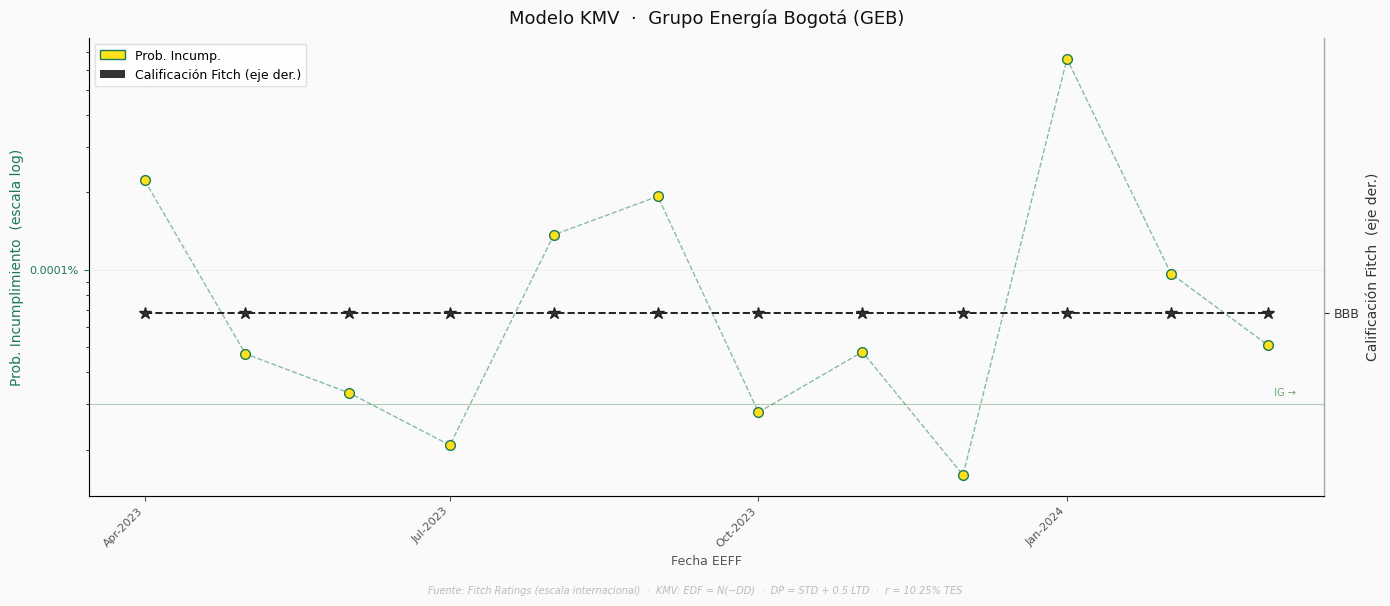

In [25]:
# =============================================================================
#  MODELO KMV — GEB (Grupo Energía Bogotá)
#  Gráfico: EDF histórica (eje izq.) vs Calificación Fitch (eje der.)
#  pip install pandas numpy yfinance scipy matplotlib
# =============================================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy.stats import norm
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS
# ─────────────────────────────────────────────────────────────────────────────
TICKER_PRECIO = "GEB.CL"
TICKER_FUND   = "GEB.CL"
TASA_RF       = 0.13    # TES Colombia
T             = 1.0       # Horizonte 1 año

# ─────────────────────────────────────────────────────────────────────────────
# ESCALA NUMÉRICA DE RATINGS (Fitch/S&P)
# Mayor número = mejor calificación
# ─────────────────────────────────────────────────────────────────────────────
ESCALA = {
    "BBB+": 15, "BBB": 14, "BBB-": 13,
    "BB+":  12, "BB":  11, "BB-":  10,
    "B+":    9, "B":    8, "B-":    7,
}
ESCALA_INV = {v: k for k, v in ESCALA.items()}

# ─────────────────────────────────────────────────────────────────────────────
# HISTORIAL DE CALIFICACIONES GEB — Fitch Ratings (internacional)
# Fuente: comunicados IR grupoenergiabogota.com + Moody's press releases
#   2018–oct-2025 : BBB  (por encima del soberano Colombia)
#   nov-2025–hoy  : BBB- (ajuste por downgrade Bogotá Distrito)
# ─────────────────────────────────────────────────────────────────────────────
RATINGS_GEB = [
    ("2017-01-01", "2025-10-31", "BBB"),
    ("2025-11-01", "2026-12-31", "BBB-"),
]

def rating_en_fecha(fecha):
    for inicio, fin, r in RATINGS_GEB:
        if pd.Timestamp(inicio) <= fecha <= pd.Timestamp(fin):
            return r
    return None

# ─────────────────────────────────────────────────────────────────────────────
# 1. PRECIOS Y VOLATILIDAD
# ─────────────────────────────────────────────────────────────────────────────
print("Descargando precios GEB.CL (7 años, mensual)...")
df_raw = yf.Ticker(TICKER_PRECIO).history(period="7y", interval="1mo")
df = df_raw[["Close"]].copy()
df.index = pd.to_datetime(df.index.tz_localize(None))
df.columns = ["Cierre"]
df["Ret_Log"]   = np.log(df["Cierre"] / df["Cierre"].shift(1))
df["Vol_Anual"] = df["Ret_Log"].rolling(12, min_periods=6).std() * np.sqrt(12)
df = df.dropna(subset=["Vol_Anual"])
print(f"  ✓ {len(df)} meses disponibles")

# ─────────────────────────────────────────────────────────────────────────────
# 2. FUNDAMENTALES
# ─────────────────────────────────────────────────────────────────────────────
print("Extrayendo fundamentales...")
empresa  = yf.Ticker(TICKER_FUND)
info     = empresa.info
acciones = info.get("sharesOutstanding", np.nan)
balance  = empresa.balance_sheet
bal      = balance.iloc[:, 0]

std = bal.get("Current Debt", bal.get("Short Long Term Debt", 0))
ltd = bal.get("Long Term Debt", bal.get("Long Term Debt And Capital Lease Obligation", 0))
std = 0 if pd.isna(std) else std
ltd = 0 if pd.isna(ltd) else ltd
DP  = std + 0.5 * ltd   # Default Point KMV

print(f"  Acciones : {acciones:,.0f}")
print(f"  STD      : {std:,.0f}")
print(f"  LTD      : {ltd:,.0f}")
print(f"  DP       : {DP:,.0f}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. ITERACIÓN MERTON
# ─────────────────────────────────────────────────────────────────────────────
def merton(E, sigma_E, D, r=TASA_RF, T=T):
    if any(pd.isna(x) or x <= 0 for x in [E, sigma_E, D]):
        return np.nan, np.nan
    def eqs(v):
        Va, sa = v
        if Va <= 0 or sa <= 0:
            return [1e9, 1e9]
        d1 = (np.log(Va/D) + (r + 0.5*sa**2)*T) / (sa*np.sqrt(T))
        d2 = d1 - sa*np.sqrt(T)
        return [Va*norm.cdf(d1) - D*np.exp(-r*T)*norm.cdf(d2) - E,
                norm.cdf(d1)*Va*sa - E*sigma_E]
    try:
        Va, sa = fsolve(eqs, [E+D, sigma_E*E/(E+D)])
        if Va <= 0 or sa <= 0:
            return np.nan, np.nan
        d1 = (np.log(Va/D) + (r + 0.5*sa**2)*T) / (sa*np.sqrt(T))
        d2 = d1 - sa*np.sqrt(T)
        return d2, norm.cdf(-d2) * 100
    except Exception:
        return np.nan, np.nan

# ─────────────────────────────────────────────────────────────────────────────
# 4. SERIE KMV HISTÓRICA
# ─────────────────────────────────────────────────────────────────────────────
print("Calculando KMV...")
resultados = []
for fecha, row in df.iterrows():
    E = acciones * row["Cierre"] if not pd.isna(acciones) else np.nan
    dd, edf = merton(E, row["Vol_Anual"], DP)
    resultados.append({"Fecha": fecha, "DD": dd, "EDF": edf,
                        "Rating": rating_en_fecha(fecha)})

kmv = pd.DataFrame(resultados).set_index("Fecha")
kmv = kmv[kmv["EDF"].between(0.00001, 99.9)]
kmv["Rating_Num"] = kmv["Rating"].map(ESCALA)

print(f"  ✓ {len(kmv)} puntos KMV válidos")
print(f"\n  Último DD  : {kmv['DD'].iloc[-1]:.3f}σ")
print(f"  Último EDF : {kmv['EDF'].iloc[-1]:.5f}%")
print(f"  Rating hoy : {kmv['Rating'].iloc[-1]}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. GRÁFICO DOBLE EJE
# ─────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
fig.patch.set_facecolor("#FAFAFA")
ax1.set_facecolor("#FAFAFA")

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
ax1.spines[["left","bottom"]].set_color("#CCCCCC")
ax2.spines["right"].set_color("#AAAAAA")
ax1.grid(axis="y", color="#E5E5E5", linewidth=0.5, linestyle="--")
ax1.grid(axis="x", color="#EEEEEE", linewidth=0.3, linestyle=":")

# ── EDF (eje izquierdo, log) ─────────────────────────────────────────────────
edf_s = kmv["EDF"].dropna()
ax1.semilogy(edf_s.index, edf_s.values,
             color="#1D7A55", linewidth=1.0, linestyle="--", alpha=0.5)
ax1.semilogy(edf_s.index, edf_s.values,
             color="#1D7A55", linewidth=0,
             marker="o", markersize=7,
             markerfacecolor="#FFE01B", markeredgecolor="#1D7A55",
             markeredgewidth=1.0, label="Prob. Incump.", zorder=3)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.4f}%"))
ax1.set_ylabel("Prob. Incumplimiento  (escala log)", fontsize=10, color="#1D7A55")
ax1.tick_params(axis="y", colors="#1D7A55", labelsize=8)
ax1.tick_params(axis="x", colors="#555555", labelsize=8)

# ── Rating (eje derecho, escalón) ────────────────────────────────────────────
rat_s = kmv["Rating_Num"].dropna()
ax2.step(rat_s.index, rat_s.values,
         color="#222222", linewidth=1.4, linestyle="--",
         where="post", label="Calificación (eje der.)", zorder=3)
ax2.plot(rat_s.index, rat_s.values,
         color="#222222", linewidth=0,
         marker="*", markersize=9,
         markerfacecolor="#333333", zorder=4)

# Etiquetas eje Y derecho — solo ratings presentes en la serie
yticks = sorted(rat_s.unique())
ax2.set_yticks(yticks)
ax2.set_yticklabels([ESCALA_INV.get(int(v), "") for v in yticks], fontsize=9)
ax2.set_ylim(min(yticks) - 2, max(yticks) + 3)
ax2.set_ylabel("Calificación Fitch  (eje der.)", fontsize=10, color="#333333")
ax2.tick_params(axis="y", colors="#333333")

# Línea vertical cuando cambia el rating
cambios = rat_s[rat_s.diff() != 0].iloc[1:]
for fecha_c in cambios.index:
    lbl = ESCALA_INV.get(int(rat_s.loc[fecha_c]), "")
    ax1.axvline(x=fecha_c, color="#888888", linewidth=0.9,
                linestyle=":", alpha=0.8)
    ax1.annotate(f" {lbl}", xy=(fecha_c, edf_s.max()),
                 fontsize=8, color="#555555", rotation=90,
                 va="top", ha="left")

# Línea horizontal: frontera Investment Grade (BBB- = 13)
ig_num = ESCALA["BBB-"]
if ax2.get_ylim()[0] < ig_num < ax2.get_ylim()[1]:
    ax2.axhline(y=ig_num, color="#2E7D32", linewidth=0.8,
                linestyle="-", alpha=0.35)
    ax2.text(kmv.index[-1], ig_num + 0.1, "  IG →",
             fontsize=7, color="#2E7D32", alpha=0.7)

# ── Eje X ────────────────────────────────────────────────────────────────────
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

# ── Título y leyenda ─────────────────────────────────────────────────────────
ax1.set_title("Modelo KMV  ·  Grupo Energía Bogotá (GEB)",
              fontsize=13, fontweight="500", color="#111111", pad=10)
ax1.set_xlabel("Fecha EEFF", fontsize=9, color="#555555")

leg_edf    = mpatches.Patch(facecolor="#FFE01B", edgecolor="#1D7A55",
                             label="Prob. Incump.")
leg_rating = mpatches.Patch(facecolor="#333333",
                             label="Calificación Fitch (eje der.)")
ax1.legend(handles=[leg_edf, leg_rating], loc="upper left",
           fontsize=9, framealpha=0.88, edgecolor="#DDDDDD", fancybox=False)

fig.text(0.5, 0.001,
         "Fuente: Fitch Ratings (escala internacional)  ·  "
         "KMV: EDF = N(−DD)  ·  DP = STD + 0.5·LTD  ·  r = 10.25% TES",
         ha="center", fontsize=7, color="#BBBBBB", fontstyle="italic")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("kmv_geb.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n  ✔  Gráfico guardado: kmv_geb.png")
plt.show()